# ASML DCF Financial Model
Author: Ana Ziu
Date: July 2026
Data Source: ASML 2024 Annual Report

This model builds a full DCF valuation of ASML Holding NV using 2024 actual financials and projects revenue through 2028. Includes sensitivity analysis and comparable company analysis.

## Section 1 - Revenue Projections
Projecting ASML revenue 2024-2028 using 10% annual growth rate based on analyst consensus at time of modelling. 2024 actual revenue €28.3bn

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Revenue Assumptions
revenue_2024 = 28.3  # €bn 2024 actual (ASML Annual Report 2024)
growth_rate = 0.10  # 10% annual growth rate - analysit consensus estimate

# Margin and Cost Assumptions
EBITDA_margin = 0.394 # 39.4% - 2024 actual (ASML Annual Report 2024)
capex_ratio = 2.07 / 28.3 # 7.3% - derived from 2024 actual capital expenditure/ revenue
tax_rate = 0.186 # 18.6% - effective tax rate 2024

# Capital Structure
net_debt = 1.05 # €bn 2024 actual (ASML Annual Report 2024)
shares = 0.39328 # bn shares - 393.28m shares outstanding (31 December 2024)

# Time Period
years = [2024, 2025, 2026, 2027, 2028]

## Section 2 - Revenue Projections
Applying constant 10% growth rate to 2024 actual revenue through 2028

ASML Revenue Projections:
 2024: € 28.3bn
 2025: € 31.1bn
 2026: € 34.2bn
 2027: € 37.7bn
 2028: € 41.4bn


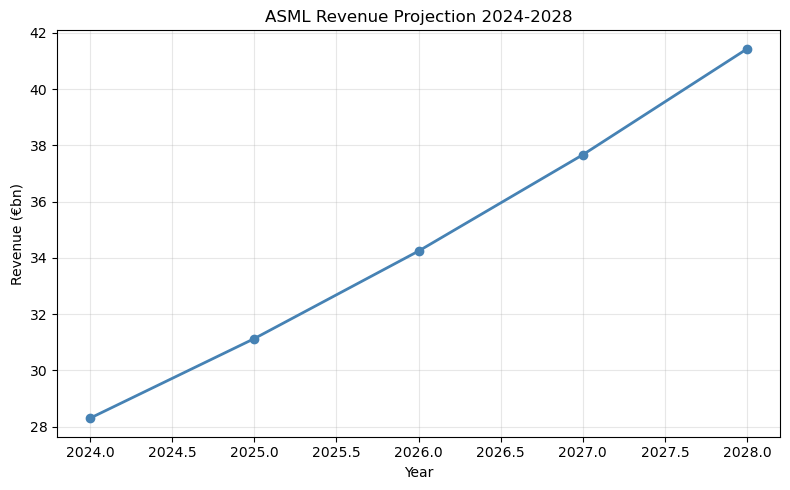

In [2]:
# Revenue Projection
revenue_2025 = revenue_2024 * (1 + growth_rate)
revenue_2026 = revenue_2025 * (1 + growth_rate)
revenue_2027 = revenue_2026 * (1 + growth_rate)
revenue_2028 = revenue_2027 * (1 + growth_rate)

revenues = [revenue_2024, revenue_2025, revenue_2026, revenue_2027, revenue_2028]

# Print Summary
print("ASML Revenue Projections:")
for y, r in zip(years, revenues):
    print(f" {y}: € {r:.1f}bn")


# Chart
plt.figure(figsize=(8,5))
plt.plot(years, revenues, marker='o', color='steelblue', linewidth=2)
plt.title( 'ASML Revenue Projection 2024-2028' )
plt.xlabel('Year')
plt.ylabel('Revenue (€bn)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3 - EBITDA Projections
Applying constant 39.4% EBITDA margin to projected revenues. 
Conservative assumption - margin held flat rather than expanding.

ASML EBITDA Projections:
 2024: € 11.2bn (margin: 39.4%)
 2025: € 12.3bn (margin: 39.4%)
 2026: € 13.5bn (margin: 39.4%)
 2027: € 14.8bn (margin: 39.4%)
 2028: € 16.3bn (margin: 39.4%)


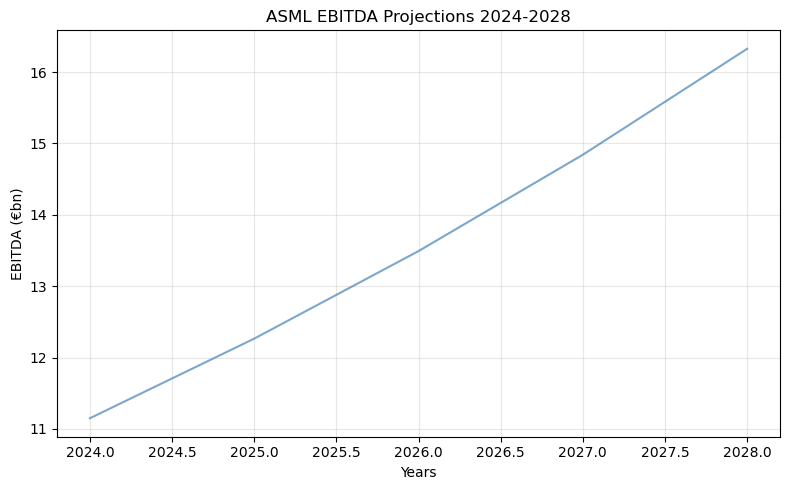

In [3]:
# EBITDA Projections
ebitda = [r * EBITDA_margin for r in revenues]

# Print Summary
print("ASML EBITDA Projections:")
for y, r in zip(years, ebitda):
    print(f" {y}: € {r:.1f}bn (margin: {EBITDA_margin:.1%})")

# Chart
plt.figure(figsize=(8,5))
plt.plot(years, ebitda, color='steelblue', alpha=0.7)
plt.title('ASML EBITDA Projections 2024-2028')
plt.xlabel('Years')
plt.ylabel('EBITDA (€bn)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4 - Free Cash Flow Projections
FCF calculated as: EBITDA minus capital expenditure minus taxes.
Capex ratio and tax rate held constant at 2024 actual levels.

In [4]:
# Free Cash Flow Projections
fcf = []
for i in range(len(revenues)):
    ebitda_value = revenues[i] * EBITDA_margin #gross operating profit
    capex = revenues[i] * capex_ratio # capital expenditure
    taxes= ebitda_value * tax_rate # tax on operating profit
    free_cash_flow=ebitda_value - taxes - capex # FCF = EBITDA - capex - taxes
    fcf.append(free_cash_flow)

# Print Summary
print("ASML Free Cash Flow Projections:")
for y, f in zip(years, fcf):
    print(f" {y}: € {f:.2f}bn")

ASML Free Cash Flow Projections:
 2024: € 7.01bn
 2025: € 7.71bn
 2026: € 8.48bn
 2027: € 9.33bn
 2028: € 10.26bn


## Section 5 - DCF Valuation
Discounting projected FCFs to present value using WACC of 9.0%.
Terminal value calculated using Gordon Growth Model with TGR of 1.75%.
Enterprise value = sum of discounted FCFs + discounted terminal value.

In [5]:
#DCF Valuation
wacc = 0.09 # 9.0%
tgr = 0.02 # terminal growth rate, 2%

# Discounted FCFs to Present Value
pv_fcf = []
for i in range(len(fcf)):
    year = i+1 #year 1,2,3,4,5
    pv=fcf[i] / (1 +wacc) ** year #Discounted to today's value
    pv_fcf.append(pv)

# Terminal Value
terminal_value= fcf[-1] * (1 + tgr)/(wacc-tgr) # Gordon Growth Method
pv_terminal = terminal_value / (1+wacc) ** 5 # discount back 5 years

# Enterprise Value
enterprise_value=sum(pv_fcf) + pv_terminal

# Print Summary
print("DCF Valuation Summary: ")
print(f" Sum of PV FCFs: € {sum(pv_fcf):.2f}bn")
print(f" Terminal Value: € {terminal_value:.2f}bn")
print(f" PV of Terminal Value: € {pv_terminal:.2f}bn")
print(f" Enterprise Value: € {enterprise_value:.2f}bn")

DCF Valuation Summary: 
 Sum of PV FCFs: € 32.73bn
 Terminal Value: € 149.47bn
 PV of Terminal Value: € 97.15bn
 Enterprise Value: € 129.88bn


## Section 6 - Implied Share Price
Equity value = enterprise value minus net debt.
Implied share price = equity value divided by shares outstanding.
Compared against market price of €738.12 at time of modelling.

In [6]:
# Implied Share Price
equity_val = enterprise_value - net_debt # remove debt obligations
implied_price = (equity_val/shares) # per share value

# Print Summary
print("Implied Share Price Analysis: ")
print(f"Equity Value: €{equity_val:.2f}bn")
print(f"Implied Share Price: €{implied_price:.0f}")
print(f"Market Price at Time of Model: €738.12")
print(f"Upside / Downside : {((implied_price - 738.12)/ 738.12):.1%}")
print()
print("Note: Discount to market price reflects ASML monpolistic premium")
print("not captured by standard DCF methodology.")

Implied Share Price Analysis: 
Equity Value: €128.83bn
Implied Share Price: €328
Market Price at Time of Model: €738.12
Upside / Downside : -55.6%

Note: Discount to market price reflects ASML monpolistic premium
not captured by standard DCF methodology.


## Section 7 - Sensitivity Analysis
Testing implied share price across WACC range 8.4-9.6% and TGR range 1.0-3.0%.
Show how sensitive the valuation is to key assumptions.

Implied Share Prices Sensitivity €
               TGR=1.0%   TGR=1.5%   TGR=2.0%   TGR=2.5%   TGR=3.0% 
WACC=8.4%        320       338       360       385       414 
WACC=8.7%        307       324       343       365       392 
WACC=9.0%        295       310       328       348       372 
WACC=9.3%        283       297       314       332       353 
WACC=9.6%        273       286       301       317       337 
WACC=8.4% prices: [319.8117108340548, 338.30982126765866, 359.69826145651336, 384.711860999411, 414.35760860580814]
WACC=8.7% prices: [306.7030356293386, 323.5524150180378, 342.91662715131906, 365.40409930609724, 391.8367420143453]
WACC=9.0% prices: [294.58328140492927, 309.98141435159863, 327.5792805763637, 347.8845108357079, 371.57394613827637]
WACC=9.3% prices: [283.3451357436974, 297.4598458957928, 313.50807798653153, 331.91634420826097, 353.2465574493127]
WACC=9.6% prices: [272.8962614038701, 285.8710299829737, 300.5530049540647, 317.3028637239008, 336.59057988310616]


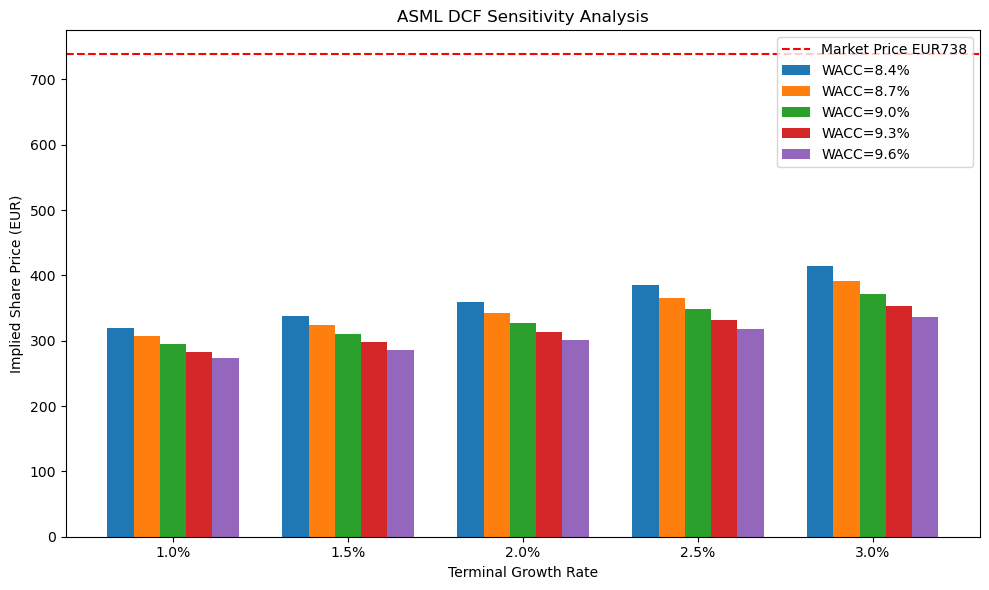

In [7]:
# Sensitivity Analysis
waccs = [0.084, 0.087, 0.09, 0.093, 0.096]
tgrs = [0.01, 0.015, 0.02, 0.025, 0.03]

print("Implied Share Prices Sensitivity €")
print(f"{' ' :>12}" , end=" ")
for t in tgrs:
    print(f"  TGR={t:.1%}", end=" ")
print()

for w in waccs:
    print(f"WACC={w:.1%} ", end=" ")
    for t in tgrs:
        tv = fcf[-1] * (1+t)/(w-t)
        pv_tv = tv / (1+w)**5
        pv_fcfs = sum([fcf[i] / (1+w) ** (1+i) for i in range(len(fcf)) ] )
        ev = pv_fcfs + pv_tv
        eq = ev - net_debt
        price = eq / shares
        print(f" {price:>8.0f}", end=" ")
    print()

# Sensitivity Analysis - Chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tgrs))
width = 0.15

for idx, w in enumerate(waccs):
    prices = []
    for t in tgrs:
        tv = fcf[-1] * (1 + t) / (w - t)
        pv_tv = tv / (1 + w) ** 5
        pv_fcfs = sum([fcf[j] / (1 + w) ** (j + 1) for j in range(len(fcf))])
        ev = pv_fcfs + pv_tv
        eq = ev - net_debt
        price = eq / shares
        prices.append(price)
    print(f"WACC={w:.1%} prices: {prices}")
    ax.bar(x + idx * width, prices, width, label=f'WACC={w:.1%}')

ax.axhline(y=738.12, color='red', linestyle='--', label='Market Price EUR738')
ax.set_xlabel('Terminal Growth Rate')
ax.set_ylabel('Implied Share Price (EUR)')
ax.set_title('ASML DCF Sensitivity Analysis')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f'{t:.1%}' for t in tgrs])
ax.legend()
plt.tight_layout()
plt.show()

## Section 8 - Comparable Company Analysis
EV/EBITDA multiples for ASML and semiconductor equipment peers.
Data sourced from analyst estimates at time of modelling.
Peer median used as valuation benchmark.

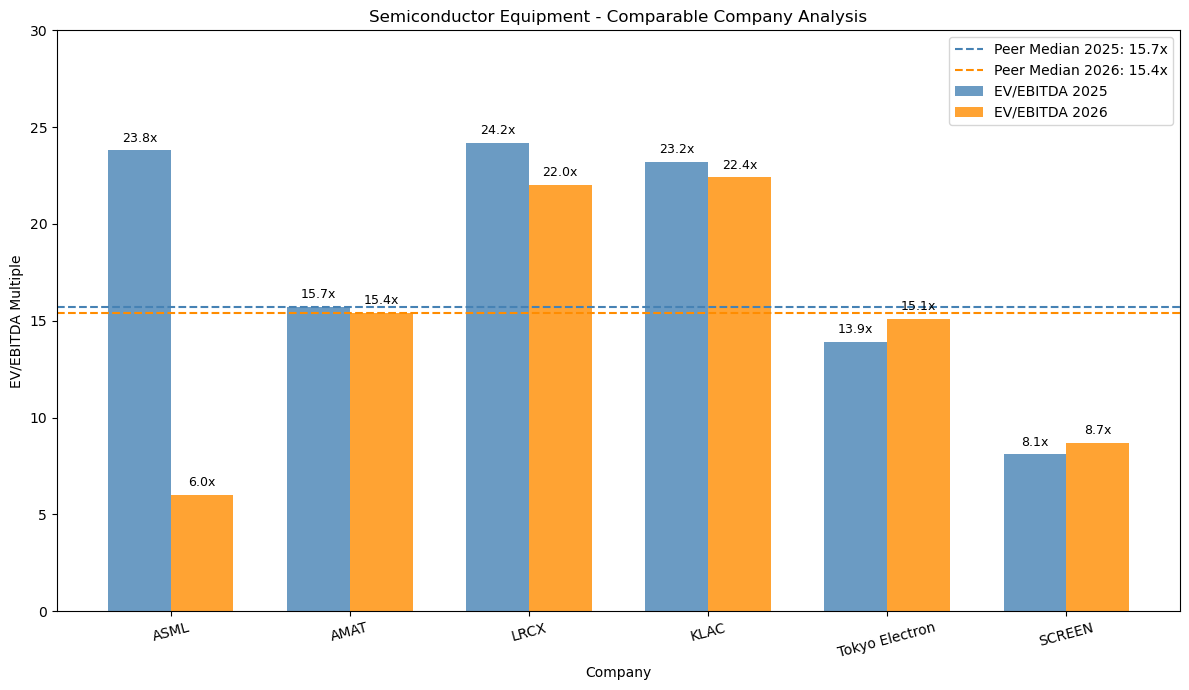

In [8]:
# Comparable Company Analysis
companies = ['ASML', 'AMAT', 'LRCX', 'KLAC', 'Tokyo Electron', 'SCREEN']

ev_ebitda_25 = [23.8, 15.7, 24.2, 23.2, 13.9, 8.1] # 2025 EV/EBITDA
ev_ebitda_26 = [6.0, 15.4, 22.0, 22.4, 15.1, 8.7] # 2026 EV/EBITDA

peer_median_25 = 15.7 # excluding ASML
peer_median_26 = 15.4 # excluding ASML

x = np.arange(len(companies))
width = 0.35

fig, ax = plt.subplots(figsize = (12,7))

bars1 = ax.bar(x - width/2, ev_ebitda_25, width, label='EV/EBITDA 2025', color='steelblue', alpha=0.8)
bars2 = ax.bar(x +width/2, ev_ebitda_26, width, label='EV/EBITDA 2026', color='darkorange', alpha=0.8)

# Peer Median Lines

ax.axhline(y=peer_median_25, color='steelblue', linestyle='--', linewidth=1.5, label=f'Peer Median 2025: {peer_median_25}x')
ax.axhline(y=peer_median_26, color='darkorange', linestyle='--', linewidth=1.5, label=f'Peer Median 2026: {peer_median_26}x')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}x', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}x', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Company')
ax.set_ylabel('EV/EBITDA Multiple')
ax.set_title('Semiconductor Equipment - Comparable Company Analysis')
ax.set_xticks(x)
ax.set_xticklabels(companies, rotation=15)
ax.legend()
ax.set_ylim(0,30)
plt.tight_layout()
plt.show()

## Section 9 - Conclusions
**DCF Implied Price:** € 273-414 across sensitivity range
**Market Price:** €738.12
**Recommendation:** Hold

**Key Findings:**
- Conservative DCF implies significant discount to market price
- ASML's monopolistic position in EUV lithography justifies premium not captured by standard DCF
- On 2025 EV/EBITDA of 23.8x ASML trades at a premium to peer median of 15.7x
- On 2026 EV/EBITDA of 6.0x ASML appears significantly undervalued - however this reflects unusual deferred revenue recognition rather than genuine undervaluation

**Limitations:**
- Constant growth rate assumption doesn't capture cyclicality in semiconductor demand
- EBITDA margin held flat - doesn't reflect potential operating leverage
- DCF methodology stuggles to capture monopoly premium and strategic optionality
- Terminal value represents 75% of eneterprise value - highly sensitive to TGR assumption

**Next Steps:**
- Incorportate analyst revenue estimates by year rather than constant growth rate
- Add sceanrio analysis - bull base, bear cases
- Model working capital and D&A explicitly for cleaner FCF calculation